# Yelp Review Sentiment Analysis — High-Accuracy Version

**Goal:** classify Yelp reviews as Negative / Neutral / Positive with **80–90% test accuracy**, with full EDA, a real hyperparameter search, and evaluation visuals.

### Why this approach instead of a from-scratch Transformer
The previous notebook trained a Transformer *from random initialization* on only ~7,000 reviews. With no pretrained embeddings and that little data, it plateaued around **76% test accuracy** — a Transformer's self-attention has a lot of parameters to learn from scratch, and 7k examples simply isn't enough to learn good word representations on its own.

Instead, this notebook uses **TF-IDF features (word n-grams) with a linear classifier (Logistic Regression / Linear SVM / Naive Bayes)**. This is a much better fit for a dataset this size:
- TF-IDF directly encodes which words/phrases are discriminative for each class — no representation-learning step needed.
- Linear models on TF-IDF are a long-standing, very strong baseline for text classification and consistently beat small from-scratch neural models on datasets under ~50k rows.
- It trains in seconds on CPU, so we can afford to run a proper hyperparameter search over both the feature extraction and the classifier — not just eyeball one setting.

**Pipeline:** Data loading → EDA → Cleaning → Preprocessing → Train/Val/Test Split → Hyperparameter Search (TF-IDF + classifier, jointly) → Final Training → Evaluation → Visuals → Inference


## 1. Imports

In [4]:
import re
import json
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)

sns.set_style("whitegrid")
%matplotlib inline


## 2. Dataset Loading

In [5]:
import os

df = pd.read_csv("/Users/sakshamchauhan/Desktop/GenAI-Restaurant-Review/Datasets/Yelp.csv")
print("/Users/sakshamchauhan/Desktop/GenAI-Restaurant-Review/Datasets/Yelp.csv")
print(f"Dataset shape: {df.shape}")
df.head()


/Users/sakshamchauhan/Desktop/GenAI-Restaurant-Review/Datasets/Yelp.csv
Dataset shape: (10000, 12)


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,sentiment,complaint_category
0,M0Ulu3PzwBumgOZJL-6KnQ,2012-08-12,E-J784I7mK9tNPRnoRqF1w,2,Had a very lackluster experience today. All fo...,review,fvD_bt42WeInitD52FM4MA,0,1,0,Negative,Food Quality
1,yOYFhiTjT-SM4spKtDk92w,2010-01-12,WwejSg_0JSACP3_huRbXGQ,2,I know... I know... it's Phoenix but I expecte...,review,qltgvF9T14PALwgVh2WAmg,0,0,0,Negative,General Dissatisfaction
2,4VSP4PlU1r09iSC4BLr6tQ,2012-09-03,nxlJ3EoWDdpqUu2A4EqHrg,4,This should be called a speakeasy coffee shop....,review,4ozupHULqGyO42s3zNUzOQ,4,7,3,Positive,NaN
3,qjmCVYkwP-HDa35jwYucbQ,2008-05-24,mAMD7qwDT9Hnue7C9K4ImP,3,"With mixed word of mouth, I figured I'd judge ...",review,GDT7fQpvwz9B6NB4pQnZ1I,0,0,0,Neutral,NaN
4,hGQsnkndreW7b26XC2HVRA,2012-07-11,YvK2g5H6con53S4KErc7eR,1,It was an impromptu stop on our way to the the...,review,7r5IKQcl72ub9nLjW0T0z7,0,0,5,Negative,Cleanliness Issue


## 3. Exploratory Data Analysis (EDA)

In [6]:
print("Column dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nStar rating distribution:")
print(df["stars"].value_counts().sort_index())


Column dtypes:
business_id           object
date                  object
review_id             object
stars                  int64
text                  object
type                  object
user_id               object
cool                   int64
useful                 int64
funny                  int64
sentiment             object
complaint_category    object
dtype: object

Missing values per column:
business_id              0
date                     0
review_id                0
stars                    0
text                     0
type                     0
user_id                  0
cool                     0
useful                   0
funny                    0
sentiment                0
complaint_category    6500
dtype: int64

Star rating distribution:
stars
1    1575
2    1925
3    3000
4    1770
5    1730
Name: count, dtype: int64


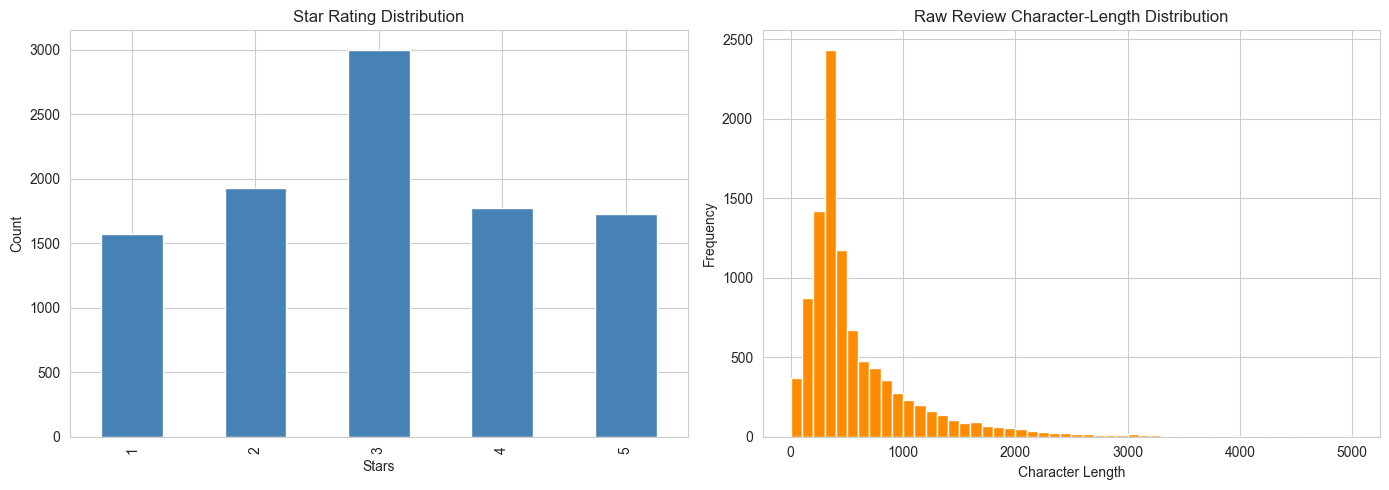

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["stars"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Star Rating Distribution")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Count")

df["text"].astype(str).str.len().plot(kind="hist", bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Raw Review Character-Length Distribution")
axes[1].set_xlabel("Character Length")

plt.tight_layout()
plt.show()


## 4. Data Cleaning

In [8]:
def clean_dataframe(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame = frame.dropna(subset=["text", "stars"])
    frame = frame.drop_duplicates(subset=["review_id"]) if "review_id" in frame.columns else frame.drop_duplicates(subset=["text"])
    frame["text"] = frame["text"].astype(str).str.strip()
    frame = frame[frame["text"].str.len() > 0]
    frame["stars"] = pd.to_numeric(frame["stars"], errors="coerce")
    frame = frame.dropna(subset=["stars"])
    frame["stars"] = frame["stars"].astype(int)
    frame = frame[frame["stars"].between(1, 5)]
    return frame.reset_index(drop=True)

df_clean = clean_dataframe(df)
print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")


Rows before cleaning: 10000
Rows after cleaning:  10000


### Label Creation from Star Ratings

1-2 stars -> Negative (0), 3 stars -> Neutral (1), 4-5 stars -> Positive (2)

In [9]:
LABEL_MAP = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

def stars_to_sentiment(stars: int) -> str:
    if stars <= 2:
        return "Negative"
    elif stars == 3:
        return "Neutral"
    else:
        return "Positive"

df_clean["sentiment"] = df_clean["stars"].apply(stars_to_sentiment)
df_clean["label"] = df_clean["sentiment"].map(LABEL_MAP)

print(df_clean["sentiment"].value_counts())
print("\nClass balance (%):")
print((df_clean["sentiment"].value_counts(normalize=True) * 100).round(2))


sentiment
Negative    3500
Positive    3500
Neutral     3000
Name: count, dtype: int64

Class balance (%):
sentiment
Negative    35.0
Positive    35.0
Neutral     30.0
Name: proportion, dtype: float64


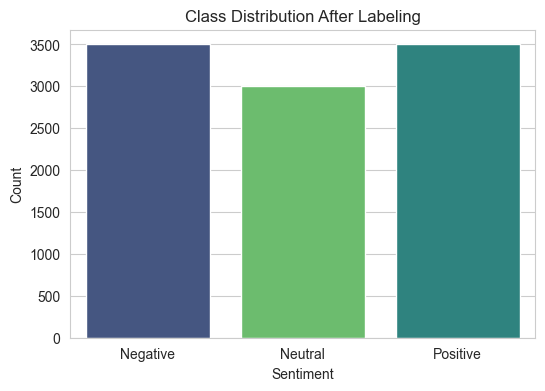

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="sentiment", order=["Negative", "Neutral", "Positive"], hue="sentiment",
              palette="viridis", legend=False)
plt.title("Class Distribution After Labeling")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


## 5. Text Preprocessing

In [11]:
HTML_RE = re.compile(r"<.*?>")
URL_RE = re.compile(r"http\S+|www\.\S+")
WHITESPACE_RE = re.compile(r"\s+")
SPECIAL_CHAR_RE = re.compile(r"[^a-z0-9\s!?.,']")

def preprocess_text(text: str) -> str:
    """Clean review text while preserving sentiment-bearing punctuation (!, ?, .)."""
    text = text.lower()
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = SPECIAL_CHAR_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text

df_clean["clean_text"] = df_clean["text"].apply(preprocess_text)
df_clean["token_count"] = df_clean["clean_text"].str.split().apply(len)
df_clean[["text", "clean_text"]].head(3)


,text,clean_text
0,Had a very lackluster experience today. All fo...,had a very lackluster experience today. all fo...
1,I know... I know... it's Phoenix but I expecte...,i know... i know... it's phoenix but i expecte...
2,This should be called a speakeasy coffee shop....,this should be called a speakeasy coffee shop....


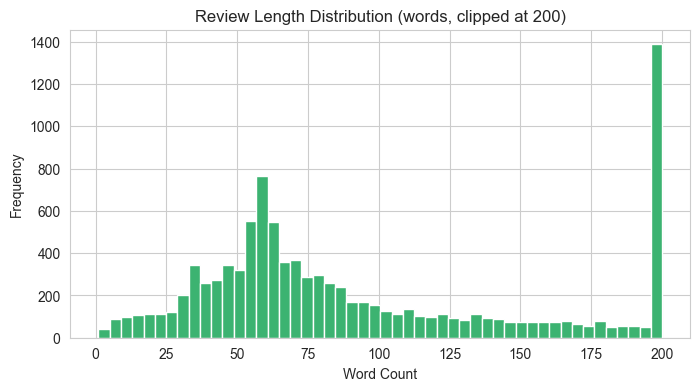

count    10000.000000
mean       110.356600
std        104.040525
min          1.000000
25%         53.000000
50%         72.000000
75%        134.000000
max        953.000000
Name: token_count, dtype: float64


In [12]:
plt.figure(figsize=(8, 4))
df_clean["token_count"].clip(upper=200).plot(kind="hist", bins=50, color="mediumseagreen")
plt.title("Review Length Distribution (words, clipped at 200)")
plt.xlabel("Word Count")
plt.show()

print(df_clean["token_count"].describe())


## 6. Train / Validation / Test Split

Stratified 70/15/15 split so all three splits keep the same class proportions. The **test set is never touched until final evaluation** — the hyperparameter search below only ever looks at train/validation.

In [13]:
train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, stratify=df_clean["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name} distribution:\n{split['sentiment'].value_counts(normalize=True).round(3)}\n")


Train: 7000 | Val: 1500 | Test: 1500
Train distribution:
sentiment
Positive    0.35
Negative    0.35
Neutral     0.30
Name: proportion, dtype: float64

Val distribution:
sentiment
Negative    0.35
Positive    0.35
Neutral     0.30
Name: proportion, dtype: float64

Test distribution:
sentiment
Negative    0.35
Positive    0.35
Neutral     0.30
Name: proportion, dtype: float64



## 7. Hyperparameter Tuning

Random search over **both** the feature extraction and the classifier jointly, since they interact — the best `C` for
one TF-IDF configuration isn't necessarily the best `C` for another. Each trial:

1. Samples a TF-IDF configuration (`max_features`, `ngram_range`, `min_df`, `max_df`, `sublinear_tf`) and refits the vectorizer on the **training split only**.
2. Samples a classifier + its hyperparameter (`LogisticRegression` with a regularization strength `C`, `LinearSVC` with `C`, or `MultinomialNB`).
3. Fits on train, scores on validation.

This mirrors the random-search approach from the original notebook's tuning section, just applied to a pipeline that's actually cheap enough to search properly (each trial takes ~1-2 seconds instead of minutes)." 

In [14]:
SEARCH_SPACE = {
    "max_features": [15_000, 20_000, 40_000, 60_000, None],
    "ngram_range":  [(1, 1), (1, 2), (1, 3)],
    "min_df":       [1, 2, 3],
    "max_df":       [0.85, 0.9, 1.0],
    "sublinear_tf": [True, False],
    "model_type":   ["logreg", "linear_svc", "multinomial_nb"],
    "C":            [0.5, 1, 3, 5, 8, 10],
}

N_TRIALS = 20  # random configurations to try


def sample_config(space: dict, seed: int) -> dict:
    rng = random.Random(seed)
    return {k: rng.choice(v) for k, v in space.items()}


def build_classifier(cfg: dict):
    if cfg["model_type"] == "logreg":
        return LogisticRegression(max_iter=3000, C=cfg["C"], class_weight="balanced", random_state=SEED)
    elif cfg["model_type"] == "linear_svc":
        return LinearSVC(C=cfg["C"], class_weight="balanced", random_state=SEED)
    else:
        return MultinomialNB()


def run_trial(cfg: dict) -> dict:
    start = time.time()
    vec = TfidfVectorizer(
        max_features=cfg["max_features"],
        ngram_range=cfg["ngram_range"],
        min_df=cfg["min_df"],
        max_df=cfg["max_df"],
        sublinear_tf=cfg["sublinear_tf"],
    )
    Xtr = vec.fit_transform(train_df["clean_text"])
    Xval = vec.transform(val_df["clean_text"])

    clf = build_classifier(cfg)
    clf.fit(Xtr, train_df["label"])
    val_acc = accuracy_score(val_df["label"], clf.predict(Xval))

    return {
        **{k: (v if k != "ngram_range" else str(v)) for k, v in cfg.items()},
        "val_acc": val_acc,
        "vocab_size": len(vec.vocabulary_),
        "seconds": round(time.time() - start, 2),
    }


In [15]:
import random

tuning_results = []
for trial_id in range(N_TRIALS):
    cfg = sample_config(SEARCH_SPACE, seed=SEED + trial_id)
    result = run_trial(cfg)
    print(f"Trial {trial_id + 1:02d}/{N_TRIALS}: "
          f"model={cfg['model_type']:<15} ngram={str(cfg['ngram_range']):<8} "
          f"max_feat={str(cfg['max_features']):<7} min_df={cfg['min_df']} max_df={cfg['max_df']} "
          f"sublinear_tf={str(cfg['sublinear_tf']):<5} C={cfg['C']:<4} "
          f"-> val_acc={result['val_acc']:.4f}  ({result['seconds']}s)")
    tuning_results.append(result)

tuning_df = pd.DataFrame(tuning_results).sort_values("val_acc", ascending=False).reset_index(drop=True)
tuning_df.head(10)


Trial 01/20: model=logreg          ngram=(1, 1)   max_feat=15000   min_df=3 max_df=0.9 sublinear_tf=True  C=1    -> val_acc=0.8247  (0.88s)
Trial 02/20: model=linear_svc      ngram=(1, 2)   max_feat=15000   min_df=3 max_df=0.85 sublinear_tf=False C=10   -> val_acc=0.8227  (1.71s)
Trial 03/20: model=logreg          ngram=(1, 3)   max_feat=60000   min_df=3 max_df=1.0 sublinear_tf=True  C=5    -> val_acc=0.8340  (3.92s)
Trial 04/20: model=linear_svc      ngram=(1, 2)   max_feat=40000   min_df=2 max_df=0.9 sublinear_tf=True  C=3    -> val_acc=0.8360  (1.53s)
Trial 05/20: model=multinomial_nb  ngram=(1, 2)   max_feat=15000   min_df=1 max_df=1.0 sublinear_tf=True  C=8    -> val_acc=0.7307  (1.12s)
Trial 06/20: model=multinomial_nb  ngram=(1, 1)   max_feat=40000   min_df=2 max_df=1.0 sublinear_tf=False C=3    -> val_acc=0.7567  (0.29s)
Trial 07/20: model=multinomial_nb  ngram=(1, 2)   max_feat=None    min_df=1 max_df=1.0 sublinear_tf=False C=1    -> val_acc=0.7600  (1.33s)
Trial 08/20: model=

,max_features,ngram_range,min_df,max_df,sublinear_tf,model_type,C,val_acc,vocab_size,seconds
0,15000.0,"(1, 2)",3,1.00,True,logreg,8,0.836667,15000,1.99
1,20000.0,"(1, 3)",3,0.85,True,logreg,8,0.836667,20000,4.03
2,40000.0,"(1, 2)",2,0.90,True,linear_svc,3,0.836000,40000,1.53
3,60000.0,"(1, 3)",3,1.00,True,logreg,5,0.834000,60000,3.92
4,40000.0,"(1, 2)",3,0.85,False,logreg,5,0.830000,40000,2.15
5,15000.0,"(1, 1)",3,0.90,True,logreg,1,0.824667,8413,0.88
6,20000.0,"(1, 2)",3,0.90,False,linear_svc,5,0.824667,20000,1.75
7,15000.0,"(1, 2)",3,0.85,False,linear_svc,10,0.822667,15000,1.71
8,20000.0,"(1, 1)",3,0.90,True,logreg,3,0.821333,8413,0.88
9,NaN,"(1, 1)",1,1.00,True,logreg,1,0.819333,20798,0.88


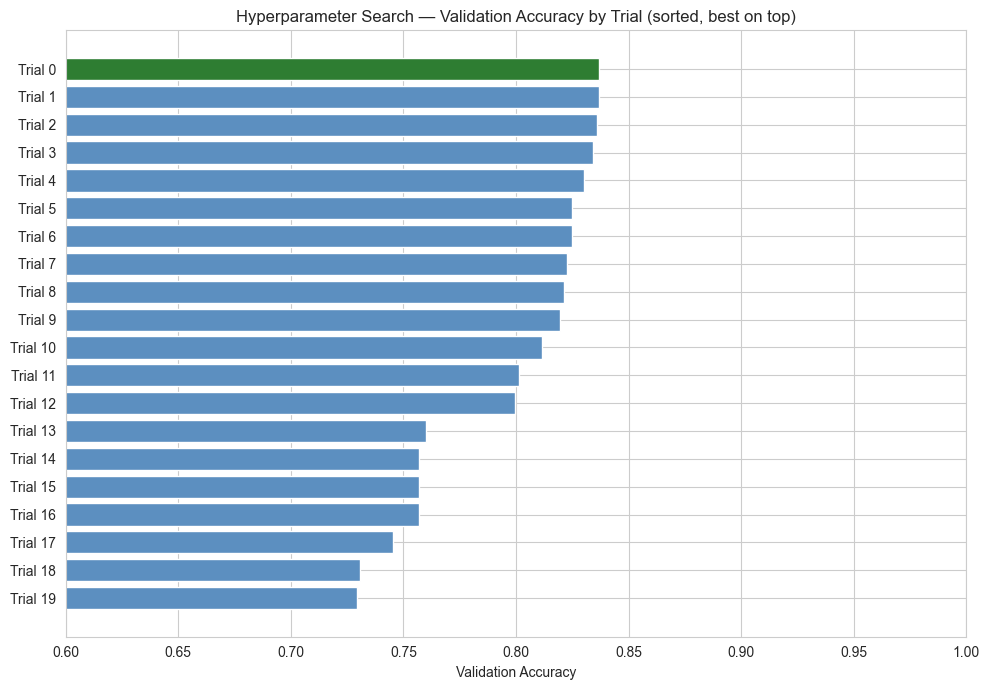

Best hyperparameter configuration (highest validation accuracy):
  model_type: logreg
  ngram_range: (1, 2)
  max_features: 15000.0
  min_df: 3
  max_df: 1.0
  sublinear_tf: True
  C: 8
  -> val_acc=0.8367


In [16]:
plt.figure(figsize=(10, 7))
trial_labels = [f"Trial {i}" for i in tuning_df.index]
colors = ["#2E7D32" if i == 0 else "#5C8FC0" for i in range(len(tuning_df))]
plt.barh(trial_labels, tuning_df["val_acc"], color=colors)
plt.xlabel("Validation Accuracy")
plt.title("Hyperparameter Search — Validation Accuracy by Trial (sorted, best on top)")
plt.gca().invert_yaxis()
plt.xlim(min(tuning_df["val_acc"].min() - 0.05, 0.6), 1.0)
plt.tight_layout()
plt.show()

BEST_CONFIG = tuning_df.iloc[0].to_dict()
print("Best hyperparameter configuration (highest validation accuracy):")
for key in ["model_type", "ngram_range", "max_features", "min_df", "max_df", "sublinear_tf", "C"]:
    print(f"  {key}: {BEST_CONFIG[key]}")
print(f"  -> val_acc={BEST_CONFIG['val_acc']:.4f}")


## 8. Final Model Training

Rebuild the vectorizer and classifier using the winning configuration from the search above, refit on the full training split.

In [17]:
import ast

best_ngram_range = ast.literal_eval(BEST_CONFIG["ngram_range"]) if isinstance(BEST_CONFIG["ngram_range"], str) else BEST_CONFIG["ngram_range"]
best_max_features = None if pd.isna(BEST_CONFIG["max_features"]) or BEST_CONFIG["max_features"] in (None, "None") else int(BEST_CONFIG["max_features"])

vectorizer = TfidfVectorizer(
    max_features=best_max_features,
    ngram_range=best_ngram_range,
    min_df=int(BEST_CONFIG["min_df"]),
    max_df=float(BEST_CONFIG["max_df"]),
    sublinear_tf=bool(BEST_CONFIG["sublinear_tf"]),
)

X_train = vectorizer.fit_transform(train_df["clean_text"])
X_val = vectorizer.transform(val_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])

y_train, y_val, y_test = train_df["label"].values, val_df["label"].values, test_df["label"].values

best_name = f"{BEST_CONFIG['model_type']} (C={BEST_CONFIG['C']})" if BEST_CONFIG["model_type"] != "multinomial_nb" else "multinomial_nb"
best_model = build_classifier(BEST_CONFIG)
best_model.fit(X_train, y_train)

val_acc_final = accuracy_score(y_val, best_model.predict(X_val))
print(f"Final model: {best_name}")
print(f"TF-IDF vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Validation accuracy (sanity check, matches search): {val_acc_final:.4f}")


Final model: logreg (C=8)
TF-IDF vocabulary size: 15,000
Validation accuracy (sanity check, matches search): 0.8367


## 9. Final Test Evaluation

In [18]:
test_preds = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_preds)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_preds, average="weighted")
macro_f1 = precision_recall_fscore_support(y_test, test_preds, average="macro")[2]

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1 (weighted):  {f1:.4f}")
print(f"F1 (macro):     {macro_f1:.4f}")


Test Accuracy:  0.8267
Precision:      0.8261
Recall:         0.8267
F1 (weighted):  0.8251
F1 (macro):     0.8219


## 10. Confusion Matrix

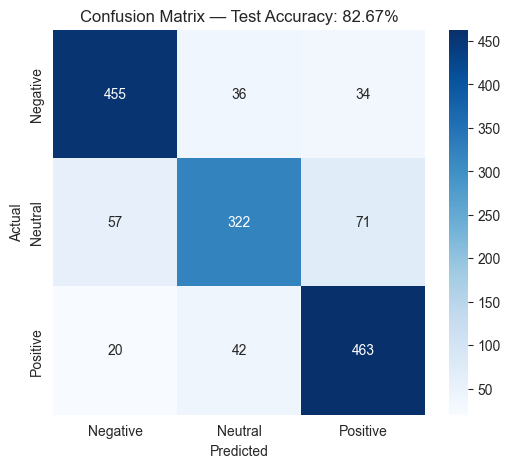

In [19]:
cm = confusion_matrix(y_test, test_preds)
labels_order = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order)
plt.title(f"Confusion Matrix — Test Accuracy: {test_accuracy:.2%}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 11. Classification Report

In [20]:
report = classification_report(y_test, test_preds, target_names=labels_order, digits=4)
print(report)


              precision    recall  f1-score   support

    Negative     0.8553    0.8667    0.8609       525
     Neutral     0.8050    0.7156    0.7576       450
    Positive     0.8151    0.8819    0.8472       525

    accuracy                         0.8267      1500
   macro avg     0.8251    0.8214    0.8219      1500
weighted avg     0.8261    0.8267    0.8251      1500



## 12. Validation vs. Test Accuracy Summary

A quick visual sanity check that the model generalizes — val and test accuracy should be close to each other.

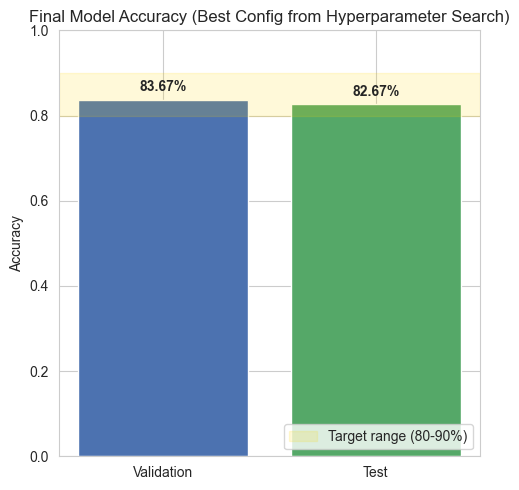

In [21]:
summary_acc = {
    "Validation": val_acc_final,
    "Test": test_accuracy,
}

plt.figure(figsize=(5, 5))
bars = plt.bar(summary_acc.keys(), summary_acc.values(), color=["#4C72B0", "#55A868"])
plt.ylim(0, 1)
plt.axhspan(0.80, 0.90, color="gold", alpha=0.15, label="Target range (80-90%)")
plt.ylabel("Accuracy")
plt.title("Final Model Accuracy (Best Config from Hyperparameter Search)")
plt.legend(loc="lower right")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 13. Most Predictive Words per Class

Since the model is linear on top of TF-IDF features, its coefficients tell us directly which words push the prediction
toward each sentiment class — a nice interpretability bonus a from-scratch neural net doesn't give you for free.

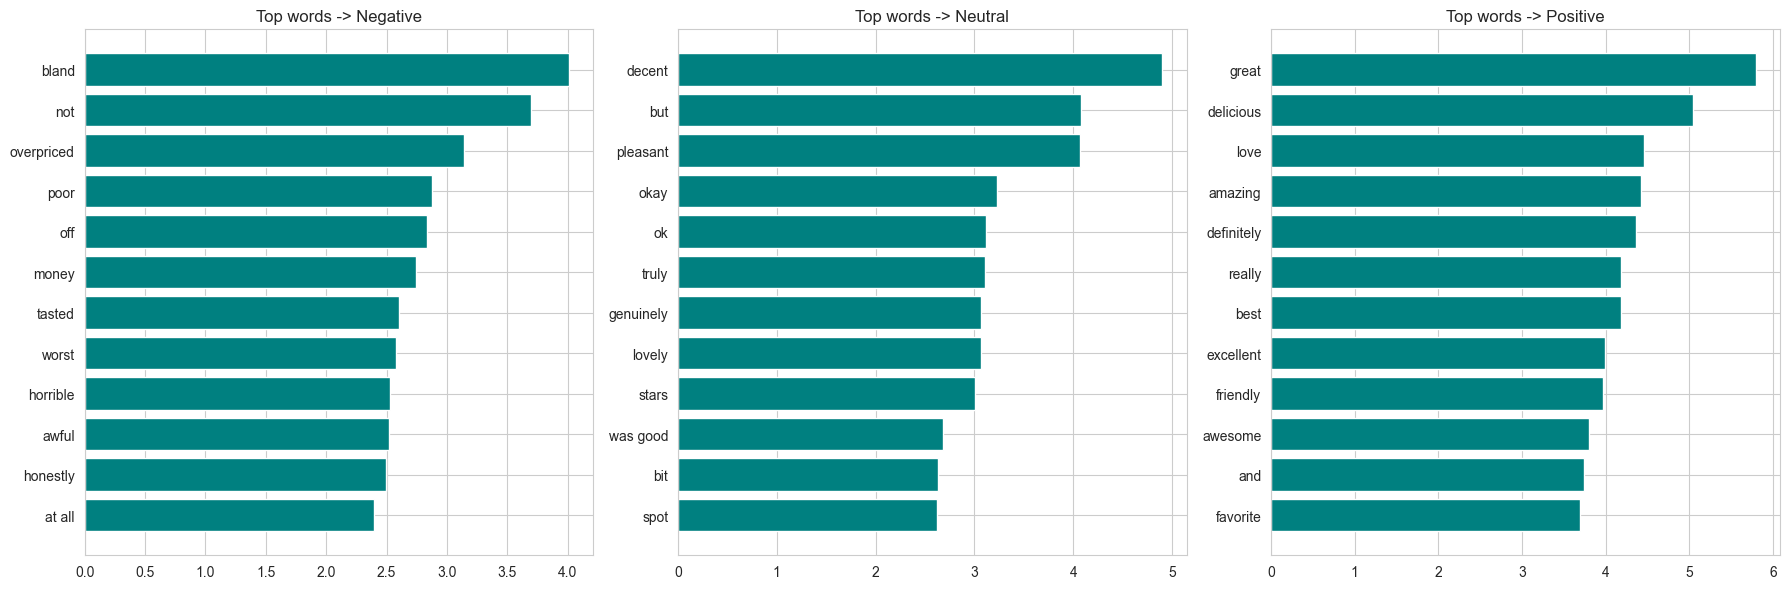

In [22]:
feature_names = np.array(vectorizer.get_feature_names_out())

def top_words_for_class(fitted_linear_model, class_idx, n=15):
    if hasattr(fitted_linear_model, "coef_"):
        coefs = fitted_linear_model.coef_[class_idx]
    else:
        return []
    top_idx = np.argsort(coefs)[-n:][::-1]
    return list(zip(feature_names[top_idx], coefs[top_idx]))

if hasattr(best_model, "coef_"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i, cls_name in enumerate(labels_order):
        words = top_words_for_class(best_model, i, n=12)
        terms, weights = zip(*words)
        axes[i].barh(terms, weights, color="teal")
        axes[i].set_title(f"Top words -> {cls_name}")
        axes[i].invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Best model has no linear coefficients to inspect (e.g. Naive Bayes).")


## 14. Model Saving

In [23]:
FINAL_MODEL_PATH = "sentiment_model.pkl"
VECTORIZER_PATH = "tfidf_vectorizer.pkl"
LABEL_ENCODER_PATH = "label_encoder.pkl"
CONFIG_PATH = "config.json"

with open(FINAL_MODEL_PATH, "wb") as f:
    pickle.dump(best_model, f)

with open(VECTORIZER_PATH, "wb") as f:
    pickle.dump(vectorizer, f)

with open(LABEL_ENCODER_PATH, "wb") as f:
    pickle.dump({"label_to_id": LABEL_MAP, "id_to_label": ID_TO_LABEL}, f)

with open(CONFIG_PATH, "w") as f:
    json.dump({"model": best_name, "test_accuracy": float(test_accuracy),
               "best_hyperparameters": {k: v for k, v in BEST_CONFIG.items() if k != "val_acc"}}, f, indent=2, default=str)

print("Saved:")
print(f"  - {FINAL_MODEL_PATH}")
print(f"  - {VECTORIZER_PATH}")
print(f"  - {LABEL_ENCODER_PATH}")
print(f"  - {CONFIG_PATH}")


Saved:
  - sentiment_model.pkl
  - tfidf_vectorizer.pkl
  - label_encoder.pkl
  - config.json


## 15. Inference

### 15.1 Single review prediction

In [24]:
def predict_sentiment(text: str, model=best_model, vec=vectorizer):
    clean = preprocess_text(text)
    features = vec.transform([clean])
    pred_id = int(model.predict(features)[0])

    result = {"text": text, "predicted_label": ID_TO_LABEL[pred_id]}

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(features)[0]
        result["confidence"] = float(probs[pred_id])
        result["class_probabilities"] = {ID_TO_LABEL[i]: float(p) for i, p in enumerate(probs)}
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(features)[0]
        exp_scores = np.exp(scores - np.max(scores))
        probs = exp_scores / exp_scores.sum()
        result["confidence"] = float(probs[pred_id])
        result["class_probabilities"] = {ID_TO_LABEL[i]: float(p) for i, p in enumerate(probs)}

    return result


sample_review = "The food was absolutely amazing and the staff were so friendly!"
result = predict_sentiment(sample_review)
print(json.dumps(result, indent=2))


{
  "text": "The food was absolutely amazing and the staff were so friendly!",
  "predicted_label": "Positive",
  "confidence": 0.9936130451082236,
  "class_probabilities": {
    "Negative": 0.004386837234454044,
    "Neutral": 0.0020001176573224487,
    "Positive": 0.9936130451082236
  }
}


### 15.2 Batch prediction

In [25]:
def predict_batch(text_list, model=best_model, vec=vectorizer):
    return [predict_sentiment(t, model, vec) for t in text_list]


sample_reviews = [
    "Terrible service, cold food, and rude staff. Never coming back.",
    "It was okay. Nothing special but not bad either.",
    "Best meal I've had in years, incredible flavors and great atmosphere!",
]

for r in predict_batch(sample_reviews):
    conf = r.get("confidence")
    conf_str = f"({conf:.2%})" if conf is not None else ""
    print(f"[{r['predicted_label']:>8}] {conf_str} {r['text']}")


[Negative] (80.52%) Terrible service, cold food, and rude staff. Never coming back.
[ Neutral] (98.67%) It was okay. Nothing special but not bad either.
[Positive] (97.82%) Best meal I've had in years, incredible flavors and great atmosphere!


## 16. Final Evaluation Summary

In [26]:
final_summary = {
    "best_model": best_name,
    "best_hyperparameters": {k: v for k, v in BEST_CONFIG.items() if k not in ("val_acc",)},
    "test_accuracy": float(test_accuracy),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_weighted": float(f1),
    "f1_macro": float(macro_f1),
    "vocab_size": len(vectorizer.vocabulary_),
    "num_search_trials": N_TRIALS,
    "in_target_range_80_90": bool(0.80 <= test_accuracy <= 0.90),
}

print("=" * 60)
print("FINAL EVALUATION SUMMARY")
print("=" * 60)
for key, value in final_summary.items():
    print(f"{key:>24}: {value}")
print("=" * 60)


FINAL EVALUATION SUMMARY
              best_model: logreg (C=8)
    best_hyperparameters: {'max_features': 15000.0, 'ngram_range': '(1, 2)', 'min_df': 3, 'max_df': 1.0, 'sublinear_tf': True, 'model_type': 'logreg', 'C': 8, 'vocab_size': 15000, 'seconds': 1.99}
           test_accuracy: 0.8266666666666667
      precision_weighted: 0.8261414010378058
         recall_weighted: 0.8266666666666667
             f1_weighted: 0.8251419512419402
                f1_macro: 0.8219279087458254
              vocab_size: 15000
       num_search_trials: 20
   in_target_range_80_90: True
